# Duolingo Forgetting Prediction

Predicting vocabulary recall probability from historical
learning behavior using Duolingo learning trace data.

In [2]:
#setup


import os
import gc

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



In [3]:
!pip install -q kaggle

In [4]:
from google.colab import userdata
import os

os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")



In [5]:
#download dataset

!mkdir -p data

!kaggle datasets download \
    kylefengkfeng209/how-fast-do-you-forget-13m-duolingo-sessions \
    -p data \
    --unzip

Dataset URL: https://www.kaggle.com/datasets/kylefengkfeng209/how-fast-do-you-forget-13m-duolingo-sessions
License(s): CC-BY-NC-SA-4.0
100% 17.1M/17.1M [00:00<00:00, 59.7MB/s]



### Problem Definition

Predict a learner's probability of recalling a vocabulary item based on previous learning interactions.

### Dataset Understanding

In [6]:
#dataset

import pandas as pd
dataset = pd.read_csv("data/learning_traces_sample.csv")

dataset

,practice_time,user_id,ui_language,learning_language,surface_form,lemma,pos,grammar_tags,lag_days,history_seen,history_correct,session_seen,session_correct,p_recall,lexeme_id
0,2013-02-28 20:11:37,u:FO,en,de,lernt,lernen,vblex,pri;p3;sg,0.003,14,12,1,0,0.000000,76390c1350a8dac31186187e2fe1e178
1,2013-02-28 20:14:53,u:g3WM,en,pt,leão,leão,n,m;sg,0.017,9,8,1,1,1.000000,4b3613233b3fede2e3e92ac2ef752bf6
2,2013-02-28 20:14:53,u:g3WM,en,pt,roupa,roupa,n,f;*numb,13.791,1,1,1,1,1.000000,3a898602c268f23d8acbeadacc9138be
3,2013-02-28 20:15:21,u:hl1O,en,de,nudeln,nudel,n,f;pl;*case,20.451,2,2,3,2,0.666667,3fb0c6ae83598ec3e6817e2e236e3b9b
4,2013-02-28 20:15:27,u:h5ex,en,de,zucker,zucker,n,m;sg;dat,0.002,2,1,1,1,1.000000,a8f2e402075e0670edf17d20c1329fa9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499431,2013-03-12 16:14:48,u:jdQ2,en,de,esst,essen,vblex,pri;p2;pl,1.166,5,4,3,3,1.000000,2429597b6723a98e21068629ab3f4231
499432,2013-03-12 16:14:51,u:hxsA,es,en,pay,pay,vblex,pres,0.004,19,17,1,0,0.000000,f6046c6b9b9cf8aa728d386c7e6100f5
499433,2013-03-12 16:14:51,u:i2Of,en,es,bebemos,beber,vblex,pri;p1;pl,0.065,6,5,2,2,1.000000,a8a620e1310deb6282fec185918acad1
499434,2013-03-12 16:14:51,u:i2Of,en,es,vino,vino,n,m;sg,0.065,11,10,2,2,1.000000,3c317e367d8d299c237e618dd5dde5da


In [7]:
dataset.head()

,practice_time,user_id,ui_language,learning_language,surface_form,lemma,pos,grammar_tags,lag_days,history_seen,history_correct,session_seen,session_correct,p_recall,lexeme_id
0,2013-02-28 20:11:37,u:FO,en,de,lernt,lernen,vblex,pri;p3;sg,0.003,14,12,1,0,0.000000,76390c1350a8dac31186187e2fe1e178
1,2013-02-28 20:14:53,u:g3WM,en,pt,leão,leão,n,m;sg,0.017,9,8,1,1,1.000000,4b3613233b3fede2e3e92ac2ef752bf6
2,2013-02-28 20:14:53,u:g3WM,en,pt,roupa,roupa,n,f;*numb,13.791,1,1,1,1,1.000000,3a898602c268f23d8acbeadacc9138be
3,2013-02-28 20:15:21,u:hl1O,en,de,nudeln,nudel,n,f;pl;*case,20.451,2,2,3,2,0.666667,3fb0c6ae83598ec3e6817e2e236e3b9b
4,2013-02-28 20:15:27,u:h5ex,en,de,zucker,zucker,n,m;sg;dat,0.002,2,1,1,1,1.000000,a8f2e402075e0670edf17d20c1329fa9


In [8]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499436 entries, 0 to 499435
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   practice_time      499436 non-null  object 
 1   user_id            499436 non-null  object 
 2   ui_language        499436 non-null  object 
 3   learning_language  499436 non-null  object 
 4   surface_form       499436 non-null  object 
 5   lemma              499436 non-null  object 
 6   pos                499436 non-null  object 
 7   grammar_tags       448480 non-null  object 
 8   lag_days           499436 non-null  float64
 9   history_seen       499436 non-null  int64  
 10  history_correct    499436 non-null  int64  
 11  session_seen       499436 non-null  int64  
 12  session_correct    499436 non-null  int64  
 13  p_recall           499436 non-null  float64
 14  lexeme_id          499436 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 57

In [9]:
dataset.describe()

,lag_days,history_seen,history_correct,session_seen,session_correct,p_recall
count,499436.000000,499436.000000,499436.000000,499436.000000,499436.000000,499436.000000
mean,8.426820,21.795071,19.229473,1.819643,1.645929,0.896076
std,25.921927,132.212007,115.861608,1.362531,1.321230,0.271270
min,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,0.006000,3.000000,3.000000,1.000000,1.000000,1.000000
50%,0.895000,6.000000,6.000000,1.000000,1.000000,1.000000
75%,5.128000,15.000000,13.000000,2.000000,2.000000,1.000000
max,466.389000,13447.000000,12821.000000,20.000000,20.000000,1.000000


In [10]:
numerical_cols = dataset.select_dtypes(include=['number']).columns
categorical_cols = dataset.select_dtypes(include=['object', 'category']).columns

numerical_data = dataset[numerical_cols]
categorical_data = dataset[categorical_cols]

print("Numerical Data:\n", numerical_data.head())
print("\nCategorical Data:\n", categorical_data.head())

Numerical Data:
    lag_days  history_seen  history_correct  session_seen  session_correct  \
0     0.003            14               12             1                0   
1     0.017             9                8             1                1   
2    13.791             1                1             1                1   
3    20.451             2                2             3                2   
4     0.002             2                1             1                1   

   p_recall  
0  0.000000  
1  1.000000  
2  1.000000  
3  0.666667  
4  1.000000  

Categorical Data:
          practice_time user_id ui_language learning_language surface_form  \
0  2013-02-28 20:11:37    u:FO          en                de        lernt   
1  2013-02-28 20:14:53  u:g3WM          en                pt         leão   
2  2013-02-28 20:14:53  u:g3WM          en                pt        roupa   
3  2013-02-28 20:15:21  u:hl1O          en                de       nudeln   
4  2013-02-28 20:15:27  u:h5ex 

### Data Quality Check

In [11]:
dataset.isnull().sum().sort_values(ascending=False)

,0
grammar_tags,50956
user_id,0
practice_time,0
learning_language,0
surface_form,0
lemma,0
ui_language,0
pos,0
lag_days,0
history_seen,0


In [12]:
#checking why grammar_tags has missing values
dataset[dataset["grammar_tags"].isnull()][
    ["surface_form", "lemma", "pos", "grammar_tags"]
].head(20)


,surface_form,lemma,pos,grammar_tags
28,not,not,adv,NaN
30,and,and,cnjcoo,NaN
39,hello,hello,ij,NaN
50,rechts,rechts,adv,NaN
55,in,in,pr,NaN
57,and,and,cnjcoo,NaN
62,plaît,plaire,@adv:s_il_te_plait,NaN
63,ne,ne,adv,NaN
65,que,que,cnjsub,NaN
67,and,and,cnjcoo,NaN


In [13]:
dataset[dataset["grammar_tags"].isnull()]["pos"].value_counts()

,count
pos,
adv,14674
pr,12858
cnjcoo,6016
ij,5011
adj,4960
...,...
@cnj:apres_que,1
@cnj:bien_que,1
@pr:afin_de,1


In [14]:
grammar_missing_by_pos = dataset.groupby("pos").agg(
    total_count=("grammar_tags", "size"),
    missing_count=("grammar_tags", lambda x: x.isna().sum())
)

grammar_missing_by_pos["missing_pct"] = (
    grammar_missing_by_pos["missing_count"]
    / grammar_missing_by_pos["total_count"]
    * 100
)

grammar_missing_by_pos.sort_values(
    ["missing_count", "missing_pct"],
    ascending=False
)

,total_count,missing_count,missing_pct
pos,,,
adv,17558,14674,83.574439
pr,15465,12858,83.142580
cnjcoo,6016,6016,100.000000
ij,5011,5011,100.000000
adj,27595,4960,17.974271
...,...,...,...
vaux,319,0,0.000000
vbdo,1336,0,0.000000
vbhaver,1603,0,0.000000


In other words, the absence of grammar_tags certainly does not appear to be random. It is very strongly linked to specific part-of-speech types.

In [15]:
dataset.duplicated().sum()

np.int64(0)

### EDA

In [16]:
dataset["p_recall"].describe()

,p_recall
count,499436.000000
mean,0.896076
std,0.271270
min,0.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,1.000000


In [17]:
dataset["p_recall"].value_counts().head(10)

,count
p_recall,
1.000000,418777
0.000000,35150
0.500000,17554
0.666667,11195
0.750000,6734
0.800000,3697
0.833333,1781
0.333333,1074
0.857143,805


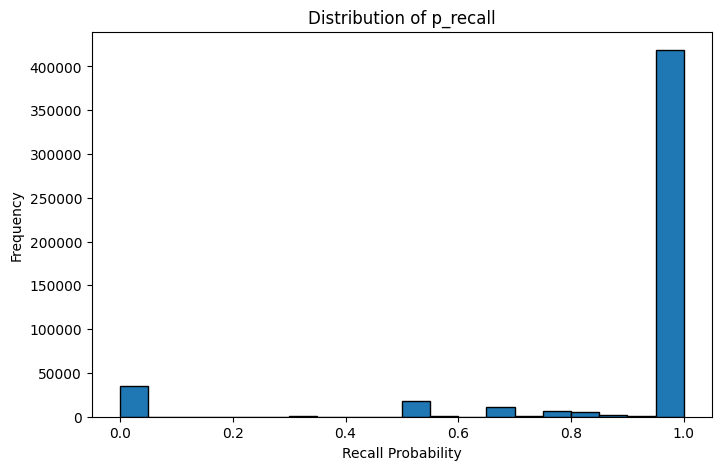

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(dataset["p_recall"], bins=20, edgecolor="black")
plt.xlabel("Recall Probability")
plt.ylabel("Frequency")
plt.title("Distribution of p_recall")
plt.show()

In [19]:
dataset["session_seen"].value_counts().sort_index()

,count
session_seen,
1,294221
2,102154
3,52963
4,26053
5,12563
6,5646
7,2481
8,1269
9,714


In [20]:
calculated_recall = dataset["session_correct"] / dataset["session_seen"]

(calculated_recall - dataset["p_recall"]).abs().max()

4.4444444458058285e-08

It was confirmed that p_recall is calculated directly from these two columns, as the difference turned out to be very close to zero. This could lead to data leakage in the future.

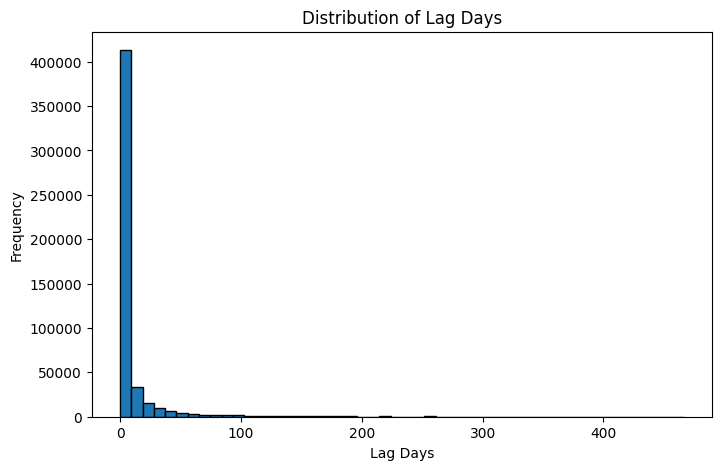

In [21]:

plt.figure(figsize=(8, 5))
plt.hist(dataset["lag_days"], bins=50, edgecolor="black")
plt.xlabel("Lag Days")
plt.ylabel("Frequency")
plt.title("Distribution of Lag Days")
plt.show()

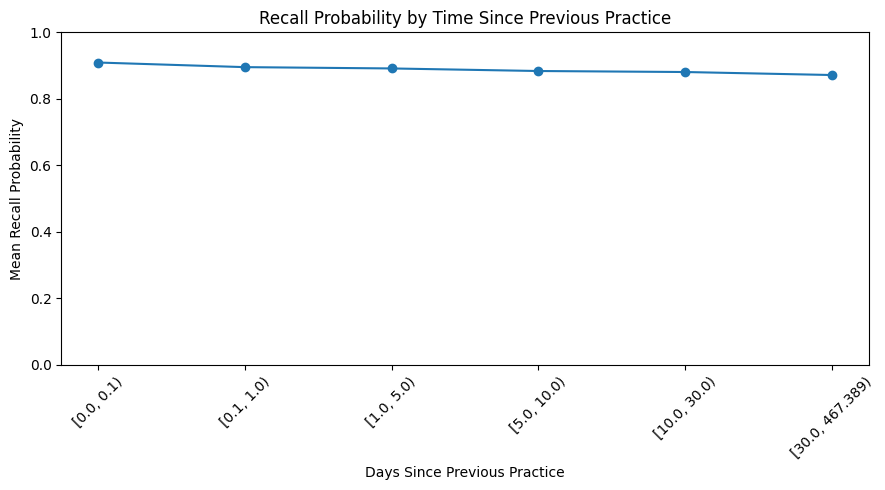

In [23]:
lag_bins = [0, 0.1, 1, 5, 10, 30, dataset["lag_days"].max() + 1]
dataset["lag_days_group"] = pd.cut(
    dataset["lag_days"],
    bins=lag_bins,
    include_lowest=True,
    right=False
)

lag_recall = dataset.groupby(
    "lag_days_group",
    observed=True
)["p_recall"].agg(["mean", "count"])

plt.figure(figsize=(9, 5))

plt.plot(
    lag_recall.index.astype(str),
    lag_recall["mean"],
    marker="o"
)

plt.xlabel("Days Since Previous Practice")
plt.ylabel("Mean Recall Probability")
plt.title("Recall Probability by Time Since Previous Practice")

plt.xticks(rotation=45)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

right-skewed distribution + weak/moderate negative correlation with recall + a future candidate for log1p.

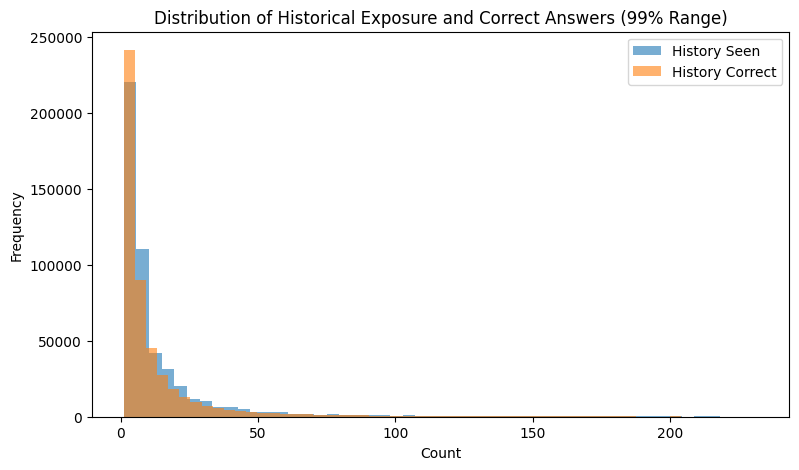

In [24]:
seen_limit = dataset["history_seen"].quantile(0.99)
correct_limit = dataset["history_correct"].quantile(0.99)

plt.figure(figsize=(9, 5))

plt.hist(
    dataset.loc[dataset["history_seen"] <= seen_limit, "history_seen"],
    bins=50,
    alpha=0.6,
    label="History Seen"
)

plt.hist(
    dataset.loc[dataset["history_correct"] <= correct_limit, "history_correct"],
    bins=50,
    alpha=0.6,
    label="History Correct"
)

plt.xlabel("Count")
plt.ylabel("Frequency")
plt.title("Distribution of Historical Exposure and Correct Answers (99% Range)")
plt.legend()
plt.show()

In [25]:
dataset["history_accuracy"] = (dataset["history_correct"] / dataset["history_seen"])

dataset['history_accuracy'].describe()

,history_accuracy
count,499436.000000
mean,0.900591
std,0.136263
min,0.090909
25%,0.833333
50%,0.964286
75%,1.000000
max,1.000000


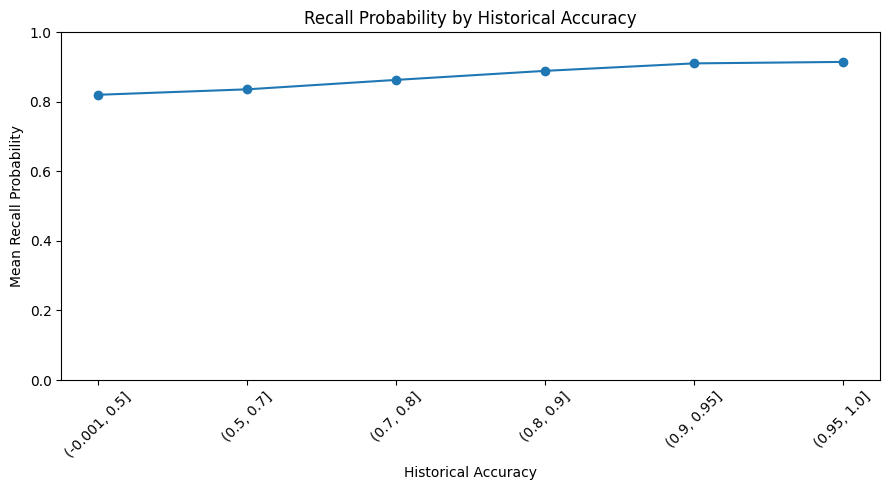

In [26]:
accuracy_bins = [0, 0.5, 0.7, 0.8, 0.9, 0.95, 1.0]

dataset["history_accuracy_group"] = pd.cut(
    dataset["history_accuracy"],
    bins=accuracy_bins,
    include_lowest=True
)

accuracy_recall = dataset.groupby(
    "history_accuracy_group",
    observed=True
)["p_recall"].agg(["mean", "count"])

plt.figure(figsize=(9, 5))

plt.plot(
    accuracy_recall.index.astype(str),
    accuracy_recall["mean"],
    marker="o"
)

plt.xlabel("Historical Accuracy")
plt.ylabel("Mean Recall Probability")
plt.title("Recall Probability by Historical Accuracy")
plt.ylim(0, 1)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

OHE candidates

In [27]:
dataset[categorical_cols].nunique().sort_values()


,0
ui_language,4
learning_language,6
pos,73
grammar_tags,585
lemma,6284
surface_form,8367
lexeme_id,11227
user_id,75294
practice_time,286983


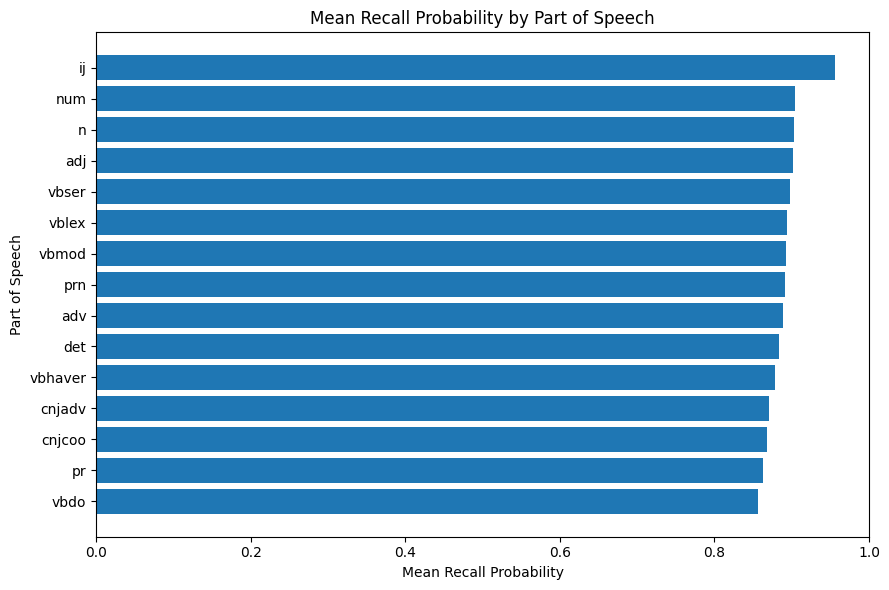

In [28]:
top_pos = dataset["pos"].value_counts().head(15).index

pos_recall = (
    dataset[dataset["pos"].isin(top_pos)]
    .groupby("pos")["p_recall"]
    .agg(["mean", "count"])
    .sort_values("mean")
)

plt.figure(figsize=(9, 6))

plt.barh(
    pos_recall.index,
    pos_recall["mean"]
)

plt.xlabel("Mean Recall Probability")
plt.ylabel("Part of Speech")
plt.title("Mean Recall Probability by Part of Speech")
plt.xlim(0, 1)

plt.tight_layout()
plt.show()

## Other Datasets

In [29]:
word_difficulty = pd.read_csv("data/word_difficulty.csv")
forgetting_curve = pd.read_csv("data/forgetting_curve.csv")
language_courses = pd.read_csv("data/language_courses.csv")

In [30]:
#first word_difficulty
print("Shape:", word_difficulty.shape)
print("Columns:", word_difficulty.columns.tolist())

word_difficulty.head()

Shape: (6211, 12)
Columns: ['learning_language', 'language_name', 'surface_form', 'lemma', 'pos', 'grammar_tags', 'n_traces', 'avg_session_recall', 'item_recall_rate', 'avg_prior_exposures', 'difficulty_rank_in_language', 'lexeme_id']


,learning_language,language_name,surface_form,lemma,pos,grammar_tags,n_traces,avg_session_recall,item_recall_rate,avg_prior_exposures,difficulty_rank_in_language,lexeme_id
0,de,German,zweiten,zweit,adj,ord;m;sg;acc,292,0.6050,0.6398,5.04,1,f58ba94f5b6a07312e449a9987637f32
1,de,German,ins,in,pr,NaN,115,0.6116,0.6736,7.37,2,360504826f856ea58070939db6aff198
2,de,German,wegen,wegen,pr,dat,109,0.6656,0.7099,6.06,3,c764a035387dc5bad1c5359f786423e0
3,de,German,größeren,groß,adj,comp;mf;pl;acc;mix,233,0.7103,0.7658,6.84,4,066aadf60b6238605b602ffe0279f993
4,de,German,vieles,viel,det,ind;nt;sg;nom,750,0.7179,0.7704,4.96,5,61ed985e99a3bdc4b497a5e0a46b104d


language_name: redundant column / drop candidate

In [31]:
word_difficulty.info()



print("Duplicates:", word_difficulty.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6211 entries, 0 to 6210
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   learning_language            6211 non-null   object 
 1   language_name                6211 non-null   object 
 2   surface_form                 6211 non-null   object 
 3   lemma                        6211 non-null   object 
 4   pos                          6211 non-null   object 
 5   grammar_tags                 5457 non-null   object 
 6   n_traces                     6211 non-null   int64  
 7   avg_session_recall           6211 non-null   float64
 8   item_recall_rate             6211 non-null   float64
 9   avg_prior_exposures          6211 non-null   float64
 10  difficulty_rank_in_language  6211 non-null   int64  
 11  lexeme_id                    6211 non-null   object 
dtypes: float64(3), int64(2), object(7)
memory usage: 582.4+ KB
Duplicates: 0


In [32]:
word_difficulty.isnull().sum()

,0
learning_language,0
language_name,0
surface_form,0
lemma,0
pos,0
grammar_tags,754
n_traces,0
avg_session_recall,0
item_recall_rate,0
avg_prior_exposures,0


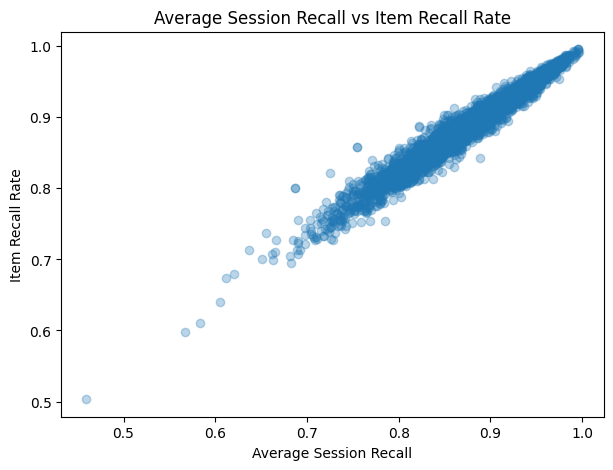

In [34]:
word_difficulty[
    ["avg_session_recall", "item_recall_rate"]
].corr()
plt.figure(figsize=(7, 5))

plt.scatter(
    word_difficulty["avg_session_recall"],
    word_difficulty["item_recall_rate"],
    alpha=0.3
)

plt.xlabel("Average Session Recall")
plt.ylabel("Item Recall Rate")
plt.title("Average Session Recall vs Item Recall Rate")

plt.show()

There is a very strong, almost linear positive correlation between avg_session_recall and item_recall_rate. In other words, as the average session recall for a word increases, the item recall rate generally increases as well. It would therefore make sense to consider in future whether these two columns need to be included in the model together; they may convey similar information. However, we are not deciding to drop them at this stage.

In [35]:
language_summary = (
    word_difficulty
    .groupby("language_name")
    .agg(
        word_count=("lexeme_id", "count"),
        mean_session_recall=("avg_session_recall", "mean"),
        mean_item_recall=("item_recall_rate", "mean")
    )
    .sort_values("mean_session_recall")
)

language_summary

,word_count,mean_session_recall,mean_item_recall
language_name,,,
French,869,0.877915,0.886524
German,1026,0.882045,0.893392
Spanish,1366,0.884730,0.896099
English,1782,0.884785,0.894383
Portuguese,382,0.902082,0.907801
Italian,786,0.909167,0.912862


In other words, in this example, the average recall for Italian and Portuguese words is slightly higher, whilst that for French is slightly lower. However, we are talking about a range of approximately 0.878–0.909; therefore, we cannot draw the conclusion that language alone determines recall.

### Preprocessing

### Feature Engineering

### Train / Validation / Test split

### Baseline model

### Model comparison

### Hyperparameter tuning

### Evaluation

### Explainability

### Review recommendation system

### Streamlit / README